#1. Setup

In [ ]:
# packages
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import random
import shutil
from PIL import Image

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on device {device}")

torch.manual_seed(256)
np.random.seed(256)

Running on device cuda:0


# **All directories are based on google colab's file structure.**

# 2. Data

Clone Repo

In [2]:
!git clone https://github.com/jfung07/UCLA_Thesis

Cloning into 'UCLA_Thesis'...
remote: Enumerating objects: 1719, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 1719 (delta 0), reused 7 (delta 0), pack-reused 1711 (from 1)
Receiving objects: 100% (1719/1719), 928.00 MiB | 76.43 MiB/s, done.
Updating files: 100% (1683/1683), done.


## 2a. CSV

In [3]:
base = "/content/UCLA_Thesis/data"
df = pd.read_excel("UCLA_Thesis/data/setters.xlsx")

### 2a1. Response Variable

Set Location

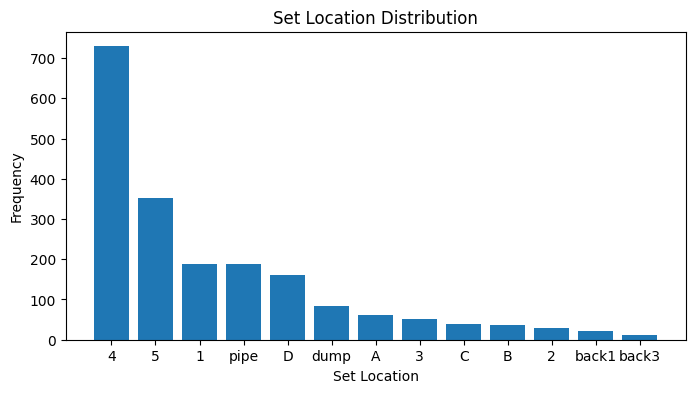

In [4]:
nums = df['set_loc'].value_counts()
fig, ax = plt.subplots(figsize = (8,4))
ax.bar(nums.index.astype(str), nums.values)
ax.set_xlabel("Set Location")
ax.set_ylabel("Frequency")
ax.set_title("Set Location Distribution")
plt.show()

2a2. Clean Set Location

In [5]:
loc_data_path = os.path.join(base, "loc_data")
os.makedirs(os.path.join(loc_data_path), exist_ok= True)
src = os.path.join(base, "setters.xlsx")
dst = os.path.join(loc_data_path, "setters.xlsx")
os.makedirs(os.path.dirname(dst), exist_ok = True)
shutil.copy(src, dst)

loc_df = pd.read_excel(os.path.join(loc_data_path, "setters.xlsx"))
loc_df['set_loc'] = loc_df['set_loc'].astype(str)
#mapping = {
    # combine 2, back1, into 1
    #"2": "1",
    #"back1": "1",
    # combine 3, 4 into 4
    #"3": "4",
    # back3 into 5
    #"back3": "5",
    # combine A, B into left_back
    #"A": "left_back",
    #"B": "left_back",
    # combine C into D
    #"C": "D"
#}
#def map_loc(x):
  #return mapping.get(x,x)

#loc_df['set_loc'] = [map_loc(x) for x in loc_df["set_loc"]]

  # midCourt group
loc_df.loc[
    loc_df["set_loc"].isin(["back1", "1", "2", "back2", "3", "dump"]),
    "set_loc"
] = "midCourt"

# 5 group
loc_df.loc[
    loc_df["set_loc"] == "back3",
    "set_loc"
] = "5"

# backRow group
loc_df.loc[
    loc_df["set_loc"].isin(["A", "B", "C", "D", "pipe"]),
    "set_loc"
] = "backRow"




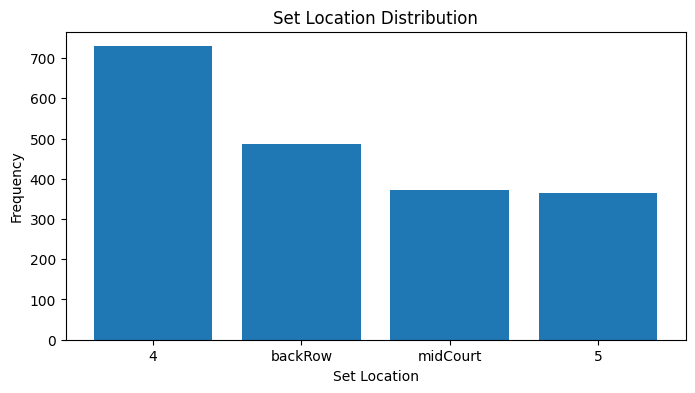

In [6]:
nums = loc_df['set_loc'].value_counts()
fig, ax = plt.subplots(figsize = (8,4))
ax.bar(nums.index.astype(str), nums.values)
ax.set_xlabel("Set Location")
ax.set_ylabel("Frequency")
ax.set_title("Set Location Distribution")
plt.show()

In [7]:
num_classes = len(loc_df['set_loc'].value_counts().index.tolist())
num_classes

4

## 2b. Images

### 2b1. Label Images

In [8]:
labeled_path = os.path.join(base, "loc_data", "labeled_set_images") # /content/UCLA_Thesis/data/loc_data/labeled_set_images
os.makedirs(labeled_path, exist_ok=True)
num_images = 0
for game_set in os.listdir(os.path.join(base, "set_images")):
  game_set_path = os.path.join(base, "set_images", game_set) # EX: /content/UCLA_Thesis/data/set_images/game2_set1
  for pos_image in os.listdir(game_set_path): # loops through images within a gameset
    if not pos_image.lower().endswith(".png"):
      continue
    csv_index = int(pos_image.replace("set", "").replace(".png", "").strip()) - 1
    label = str(loc_df['set_loc'][csv_index])
    class_folder = os.path.join(labeled_path, game_set, label)
    os.makedirs(class_folder, exist_ok=True)
    shutil.copy(os.path.join(game_set_path, pos_image), os.path.join(labeled_path, game_set, class_folder, pos_image)) # from original to labeled path
    num_images += 1

print(f"labeled {num_images} images")

labeled 1677 images


###2b2. Split within game

In [9]:
# folders
splits = ["train", "val", "test"]
split_images_path = os.path.join(base, "loc_data", "setLoc_split") # /content/UCLA_Thesis/data/loc_data/setLoc_split
os.makedirs(split_images_path, exist_ok=True)
for game_set in os.listdir(labeled_path): # labeled path = /content/UCLA_Thesis/data/loc_data/labeled_set_images
  game_set_splits_path = os.path.join(split_images_path, game_set) # EX. /content/UCLA_Thesis/data/loc_data/setLoc_split/game2_set1
  for s in splits:
    os.makedirs(os.path.join(game_set_splits_path, s), exist_ok=True)

In [10]:
# populate
np.random.seed(256)
for game_set in os.listdir(labeled_path): # labeled path = /content/UCLA_Thesis/data/loc_data/labeled_set_images
  game_set_path = os.path.join(labeled_path, game_set) # EX. /content/UCLA_Thesis/data/loc_data/labeled_set_images/game2_set1
  for loc in os.listdir(game_set_path):
    loc_path = os.path.join(game_set_path, loc) # EX. /content/UCLA_Thesis/data/loc_data/labeled_set_images/game2_set1/1
    imgs = [f for f in os.listdir(loc_path) if f.lower().endswith(".png")]
    random.shuffle(imgs)
    n = len(imgs)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    train_imgs, val_imgs, test_imgs = imgs[:train_end], imgs[train_end:val_end], imgs[val_end:]
    # loc within split
    for s in splits:
      # make folders
      os.makedirs(os.path.join(split_images_path, game_set, s, loc), exist_ok = True)
    for subset, subset_imgs in zip(splits, [train_imgs, val_imgs, test_imgs]):
      outdir = os.path.join(split_images_path, game_set, subset, loc)

      for file in subset_imgs:
        shutil.copy(os.path.join(loc_path, file), os.path.join(outdir, file))

#### CSV lines based on image split

##### Train

In [11]:
loc_train_df = pd.DataFrame()
# loop through game sets in split
split_images_path = os.path.join(base, "loc_data", "setLoc_split")
for game_set in os.listdir(split_images_path):
  # go through train of each game
  train_path = os.path.join(split_images_path, game_set, "train")
  # loop through locations
  for loc in os.listdir(train_path):
    loc_path = os.path.join(train_path, loc)
    for pos_image in os.listdir(loc_path):
      csv_index = int(pos_image.replace("set", "").replace(".png", "").strip()) - 1
      row = df.loc[csv_index]
      loc_train_df = pd.concat([loc_train_df, row.to_frame().T], ignore_index=True)

out_path = "/content/UCLA_Thesis/data/loc_data/train.xlsx"
os.makedirs(os.path.dirname(out_path), exist_ok = True)
loc_train_df.to_excel(out_path, index = False)

In [12]:
print(len(loc_train_df))
loc_train_df.head(5)

1129


,observation,points1,points2,team1_diff,team2_diff,tot_point,set,game,rotation,receiver_loc,pass_loc,pass_quality,set_loc,num_block,set_receiver,kill,team,level,game_sex
0,1862,6,4,2,-2,10,3,8,3,5,3,4,5,2,opposite1,1,japanM,Pro,M
1,1873,10,9,1,-1,19,3,8,3,5,3,4,5,1,opposite1,1,france,Pro,M
2,1878,15,10,5,-5,25,3,8,2,1,3,4,5,2,opposite1,1,japanM,Pro,M
3,1898,21,17,4,-4,38,3,8,4,5,7,5,D,1,opposite1,1,france,Pro,M
4,1888,19,14,5,-5,33,3,8,3,6,3,4,pipe,1,outside3,0,france,Pro,M


##### Validation

In [13]:
loc_val_df = pd.DataFrame()
# loop through game sets in split
split_images_path = os.path.join(base, "loc_data", "setLoc_split")
for game_set in os.listdir(split_images_path):
  # go through val of each game
  val_path = os.path.join(split_images_path, game_set, "val")
  # loop through locations
  for loc in os.listdir(val_path):
    loc_path = os.path.join(val_path, loc)
    for pos_image in os.listdir(loc_path):
      csv_index = int(pos_image.replace("set", "").replace(".png", "").strip()) - 1
      row = df.loc[csv_index]
      loc_val_df = pd.concat([loc_val_df, row.to_frame().T], ignore_index=True)

out_path = "/content/UCLA_Thesis/data/loc_data/val.xlsx"
os.makedirs(os.path.dirname(out_path), exist_ok = True)
loc_val_df.to_excel(out_path, index = False)

In [14]:
print(len(loc_val_df))
loc_val_df.head(5)

246


,observation,points1,points2,team1_diff,team2_diff,tot_point,set,game,rotation,receiver_loc,pass_loc,pass_quality,set_loc,num_block,set_receiver,kill,team,level,game_sex
0,1891,19,15,4,-4,34,3,8,3,3,3,4,5,2,opposite1,1,france,Pro,M
1,1887,19,14,5,-5,33,3,8,6,2,3,2,A,2,outside3,0,japanM,Pro,M
2,1865,6,5,1,-1,11,3,8,6,5,3,4,D,2,opposite1,1,france,Pro,M
3,1876,14,10,4,-4,24,3,8,2,4,4,3,B,0,outside1,0,japanM,Pro,M
4,1856,2,1,1,-1,3,3,8,6,5,4,3,4,2,outside1,0,japanM,Pro,M


##### Test

In [15]:
loc_test_df = pd.DataFrame()
# loop through game sets in split
split_images_path = os.path.join(base, "loc_data", "setLoc_split")
for game_set in os.listdir(split_images_path):
  # go through test of each game
  test_path = os.path.join(split_images_path, game_set, "test")
  # loop through locations
  for loc in os.listdir(test_path):
    loc_path = os.path.join(test_path, loc)
    for pos_image in os.listdir(loc_path):
      csv_index = int(pos_image.replace("set", "").replace(".png", "").strip()) - 1
      row = df.loc[csv_index]
      loc_test_df = pd.concat([loc_test_df, row.to_frame().T], ignore_index=True)

out_path = "/content/UCLA_Thesis/data/loc_data/test.xlsx"
os.makedirs(os.path.dirname(out_path), exist_ok = True)
loc_test_df.to_excel(out_path, index = False)

In [16]:
print(len(loc_test_df))
loc_test_df.head(5)

302


,observation,points1,points2,team1_diff,team2_diff,tot_point,set,game,rotation,receiver_loc,pass_loc,pass_quality,set_loc,num_block,set_receiver,kill,team,level,game_sex
0,1874,12,9,3,-3,21,3,8,1,6,6,2,5,2,opposite1,0,japanM,Pro,M
1,1896,20,15,5,-5,35,3,8,1,1,7,5,pipe,2,outside1,0,japanM,Pro,M
2,1870,9,8,1,-1,17,3,8,3,6,3,4,pipe,1,outside1,0,france,Pro,M
3,1895,20,15,5,-5,35,3,8,4,4,5,1,pipe,0,setter1,0,france,Pro,M
4,1872,10,8,2,-2,18,3,8,6,6,3,3,4,2,outside3,1,japanM,Pro,M


Delete labeled_set_images

In [17]:
shutil.rmtree(labeled_path)

###2b3. Combined Split

Train

In [18]:
split_comb_path = os.path.join(base, "loc_data", "split_comb") # /content/UCLA_Thesis/data/loc_data/split_comb
os.makedirs(os.path.dirname(split_comb_path), exist_ok=True)
train_comb_path = os.path.join(split_comb_path, "train_comb") # /content/UCLA_Thesis/data/loc_data/split_comb/train_comb
os.makedirs(os.path.dirname(train_comb_path), exist_ok=True)
# loop through game sets
for game_set in os.listdir(split_images_path):
  # collect all train images across game sets
  game_set_train = os.path.join(base, "loc_data", "setLoc_split", game_set, "train") # /content/UCLA_Thesis/data/loc_data/setLoc_split/game2_set1/train
  for loc in os.listdir(game_set_train):
    loc_comb_path = os.path.join(train_comb_path, loc)
    os.makedirs(loc_comb_path, exist_ok=True)
    loc_path = os.path.join(game_set_train, loc)
    for pos_img in os.listdir(loc_path):
      src = os.path.join(loc_path, pos_img)
      dst = os.path.join(loc_comb_path, pos_img)
      os.makedirs(os.path.dirname(dst), exist_ok=True)
      shutil.copy(src, dst)

Val

In [19]:
val_comb_path = os.path.join(split_comb_path, "val_comb") # /content/UCLA_Thesis/data/loc_data/split_comb/val_comb
os.makedirs(os.path.dirname(val_comb_path), exist_ok=True)
# loop through game sets
for game_set in os.listdir(split_images_path):
  # collect all validation images across game sets
  game_set_val = os.path.join(base, "loc_data", "setLoc_split", game_set, "val") # /content/UCLA_Thesis/data/loc_data/setLoc_split/game2_set1/val
  for loc in os.listdir(game_set_val):
    loc_comb_path = os.path.join(val_comb_path, loc)
    os.makedirs(loc_comb_path, exist_ok=True)
    loc_path = os.path.join(game_set_val, loc)
    for pos_img in os.listdir(loc_path):
      src = os.path.join(loc_path, pos_img)
      dst = os.path.join(loc_comb_path, pos_img)
      os.makedirs(os.path.dirname(dst), exist_ok=True)
      shutil.copy(src, dst)

Test

In [20]:
test_comb_path = os.path.join(split_comb_path, "test_comb") # /content/UCLA_Thesis/data/loc_data/split_comb/test_comb
os.makedirs(os.path.dirname(test_comb_path), exist_ok=True)
# loop through game sets
for game_set in os.listdir(split_images_path):
  # collect all testing images across game sets
  game_set_test = os.path.join(base, "loc_data", "setLoc_split", game_set, "test") # /content/UCLA_Thesis/data/loc_data/setLoc_split/game2_set1/test
  for loc in os.listdir(game_set_test):
    loc_comb_path = os.path.join(test_comb_path, loc)
    os.makedirs(loc_comb_path, exist_ok=True)
    loc_path = os.path.join(game_set_test, loc)
    for pos_img in os.listdir(loc_path):
      src = os.path.join(loc_path, pos_img)
      dst = os.path.join(loc_comb_path, pos_img)
      os.makedirs(os.path.dirname(dst), exist_ok=True)
      shutil.copy(src, dst)

### 2b3. Transform Images

Get data mean and standard deviation for normalizing.  For this project, I am not analyzing within game, so I use the combination of all game set training sets, and same for the validation and test sets.  However, I split the data such that other research can analyze data within games.

In [21]:
means = []
stdevs = []
for loc in os.listdir(train_comb_path):
  for pos in os.listdir(os.path.join(train_comb_path, loc)):
    if not pos.lower().endswith((".png")):
      continue
    path = os.path.join(train_comb_path, loc, pos)
    img = Image.open(path).convert("RGB")
    arr = np.array(img) / 255.0
    means.append(arr.mean(axis = (0,1)))
    stdevs.append(arr.std(axis = (0,1)))
train_mean = np.mean(means, axis = 0)
train_stdev = np.mean(stdevs, axis = 0)
print(f"Mean: {train_mean} and Stdev: {train_stdev}")

Mean: [0.42345353 0.40084879 0.4140592 ] and Stdev: [0.34063567 0.27878794 0.2556217 ]


####Transforms

In [22]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p = 0.5), # keeps ground and ceiling orientation
    # random cropping
    transforms.RandomResizedCrop(
      size = (1024, 512),
      scale = (0.8, 1.0),
      ratio = (1.8, 2.2)
    ),
    # random color
    transforms.ColorJitter(
        brightness = 0.2,
        contrast = 0.2,
        saturation = 0.2,
        hue = 0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean = train_mean, std = train_stdev)
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = train_mean, std = train_stdev)
])

Transform Data

In [23]:
train_ds = datasets.ImageFolder(train_comb_path,
                                transform = train_transform)
val_ds = datasets.ImageFolder(val_comb_path,
                              transform = val_test_transform)
test_ds = datasets.ImageFolder(test_comb_path,
                               transform = val_test_transform)
print(f"Training samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")

Training samples: 1129
Validation samples: 246
Test samples: 302


###2b4. Data Loader

Use batch sizes of either 8 or 16 because images are large on a medium size data set.
Choices:
- 8
  - lr = 0.0001 with adam or
  - lr = 0.01, momentum = 0.9 with sgd
  - scaler = torch.cuda.amp.GradScaler()
  - num_workers = 2(colab)
- 16
  - lr = 0.0002 with adam or
  - lr = 0.02, momentum = 0.9 with sgd
  - scaler = torch.cuda.amp.GradScaler()
  - num_workers = 4(colab)

Use batch_size = 8 because VGG prefers it and works well with the simple model as well.

Loader for batch_size = 8

In [24]:
train_loader8 = DataLoader(train_ds, batch_size = 8, shuffle = True,
                           num_workers = 2, pin_memory = True,
                           persistent_workers=True)
val_loader8 = DataLoader(val_ds, batch_size = 8, shuffle = False,
                           num_workers = 2, pin_memory = True,
                           persistent_workers=True)
test_loader8 = DataLoader(test_ds, batch_size = 8, shuffle = False,
                           num_workers = 2, pin_memory = True,
                           persistent_workers=True)
print("For batch_size = 8:")
print(f"Number of training batches: {len(train_loader8)}")
print(f"Number of validation batches: {len(val_loader8)}")
print(f"Number of test batches: {len(test_loader8)}")

For batch_size = 8:
Number of training batches: 142
Number of validation batches: 31
Number of test batches: 38


bs = 8 structure

In [25]:
images, labels = next(iter(train_loader8))

print(f"Batch shape: {images.shape}")   # [batch_size, channels, height, width]
print(f"Labels shape: {labels.shape}")  # [batch_size]
print(f"Image dtype: {images.dtype}")
print(f"Label dtype: {labels.dtype}")

Batch shape: torch.Size([8, 3, 1024, 512])
Labels shape: torch.Size([8])
Image dtype: torch.float32
Label dtype: torch.int64


#3. Model

## 3a. Simple Baseline

In [26]:
class SimpleCNN(nn.Module):
  def __init__(self, num_classes = 7):
    super(SimpleCNN, self).__init__()
    # input is 1024x512x3 image

    # Block 1: 1024x512 -> 512x256
    self.block1 = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, stride = 1, padding = 1), # (32 filters, 3x3(kernel), padding = 1)
        nn.ReLU(inplace = True), #-> ReLU
        nn.MaxPool2d(kernel_size=2), # -> max pool 2x2
    )

    # Block 2: 512x256 -> 256x128
    self.block2 = nn.Sequential(
        nn.Conv2d(32, 64, kernel_size=3, stride = 1, padding = 1),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size = 2),
    )

    # Block 3: 256x128 -> 128x64
    self.block3 = nn.Sequential(
        nn.Conv2d(64, 64, kernel_size=3, stride = 1, padding = 1),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size=2),
    )

    # Block 4: 128x64 -> 64x32
    self.block4 = nn.Sequential(
        nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2),
    )

    # Flatten Layer 64x32x64 -> 64*32*64
    self.flatten = nn.Flatten()

    # Fully Connected Later: 64*32*64 -> 64
    self.layer1 = nn.Linear(64 * 32 * 64, 64)
    self.activation = nn.ReLU()

    # Output Layer: 64 -> 7
    self.classifier = nn.Linear(64, num_classes)

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.block4(x)
    x = self.flatten(x)
    x = self.activation(self.layer1(x))
    x = self.classifier(x)
    return x


### Summary

In [27]:
simple_model = SimpleCNN(num_classes=7).to(device)

# Print model architecture
print(simple_model)
print(f"\nTotal parameters: {sum(p.numel() for p in simple_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in simple_model.parameters() if p.requires_grad):,}")

SimpleCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=131072, out_features=64, bias=True)
  (activation): R

## 3b. VGG

In [28]:
from torch.nn.modules.batchnorm import BatchNorm2d

class VGG(nn.Module):
  def __init__(self, num_classes = 7):
    super().__init__()

    # Block 1: 1024x512 -> 512x256
    self.block1 = nn.Sequential(
      nn.Conv2d(3, 32, kernel_size=3, padding=1),
      BatchNorm2d(32),
      nn.ReLU(inplace = True),
      nn.MaxPool2d(2, 2),
    )

    # Block 2: 512x256 -> 256x128
    self.block2 = nn.Sequential(
      nn.Conv2d(32, 64, kernel_size=3, padding=1),
      BatchNorm2d(64),
      nn.ReLU(inplace = True),
      nn.MaxPool2d(2, 2),
    )

    # Block 3: 256x128 -> 128x64
    self.block3 = nn.Sequential(
      nn.Conv2d(64, 128, kernel_size=3, padding=1),
      BatchNorm2d(128),
      nn.ReLU(inplace = True),
      nn.Conv2d(128, 128, kernel_size=3, padding=1),
      BatchNorm2d(128),
      nn.ReLU(inplace = True),
      nn.MaxPool2d(2, 2),
    )

    # Block 4: 128x64 -> 64x32
    self.block4 = nn.Sequential(
      nn.Conv2d(128, 256, kernel_size=3, padding=1),
      BatchNorm2d(256),
      nn.ReLU(inplace = True),
      nn.Conv2d(256, 256, kernel_size=3, padding=1),
      BatchNorm2d(256),
      nn.ReLU(inplace = True),
      nn.MaxPool2d(2, 2),
    )

    # Block 5: 64x32 -> 32x16
    self.block5 = nn.Sequential(
      nn.Conv2d(256, 512, kernel_size=3, padding=1),
      BatchNorm2d(512),
      nn.ReLU(inplace = True),
      nn.Conv2d(512, 512, kernel_size=3, padding=1),
      BatchNorm2d(512),
      nn.ReLU(inplace = True),
      nn.MaxPool2d(2, 2),
    )

    self.gap = nn.AdaptiveAvgPool2d((1,1))
    self.classifier = nn.Linear(512, num_classes)

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.block4(x)
    x = self.block5(x)
    x = self.gap(x)
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

### Summary

In [29]:
vgg_model = VGG(num_classes=7).to(device)

# Print model architecture
print(vgg_model)
print(f"\nTotal parameters: {sum(p.numel() for p in vgg_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in vgg_model.parameters() if p.requires_grad):,}")

VGG(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

# 4. Training and Evaluation Helpers

## 4a. Training Helper

In [30]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, scaler):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Zero gradients
        optimizer.zero_grad(set_to_none=True)

        # Forward pass
        with torch.cuda.amp.autocast():
          outputs = model(images)
          loss = criterion(outputs, labels)

        # Backward pass
        scaler.scale(loss).backward()

        # Update weights
        scaler.step(optimizer)
        scaler.update()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * running_correct / total
    return epoch_loss, epoch_acc

## 4b. Evaluation Helpers

In [31]:
def evaluate(model, val_loader, criterion, device):
    """Evaluate the model on test set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [32]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
def plot_confusion_matrix(model, test_loader, devce, classes):
  model.eval()
  y_pred = []
  y_true = []

  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = outputs.max(1)

      y_pred.extend(predicted.cpu().numpy())
      y_true.extend(labels.cpu().numpy())

  cm = confusion_matrix(y_true, y_pred)
  return cm


#5. Run Basic CNN

Configuration

In [33]:
# Training configuration
NUM_EPOCHS = 20
LEARNING_RATE = 0.0001

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(simple_model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_1059/126794699.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


##5a. Train

In [34]:
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("Starting training...")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Validation Loss':<12} {'Validation Acc':<12}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(simple_model, train_loader8, criterion, optimizer, device, scaler)

    # Evaluate
    val_loss, val_acc = evaluate(simple_model, val_loader8, criterion, device)

    # Update scheduler
    scheduler.step(val_loss)

    # Save metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.2f} {val_loss:<12.4f} {val_acc:<12.2f}")

print("\nTraining complete!")

Starting training...
Epoch    Train Loss   Train Acc    Validation Loss Validation Acc
------------------------------------------------------------


/tmp/ipykernel_1059/3757051921.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


1        1.4621       35.43        1.3819       37.80       
2        1.3643       35.25        1.3712       25.61       
3        1.3524       37.29        1.3720       28.86       
4        1.3386       38.88        1.3313       39.43       
5        1.3248       39.59        1.3487       37.80       
6        1.3179       39.86        1.3531       35.37       
7        1.3113       40.39        1.3803       29.27       
8        1.2932       41.45        1.3618       35.37       
9        1.2876       42.16        1.3533       32.93       
10       1.2800       40.48        1.3927       30.49       
11       1.2745       42.78        1.3875       29.67       
12       1.2638       43.31        1.3730       32.93       
13       1.2515       43.40        1.3837       32.52       
14       1.2529       41.90        1.3810       34.15       
15       1.2536       42.78        1.3841       32.93       
16       1.2389       43.31        1.3999       31.30       
17       1.2480       43

## 5b. Accuracy and Loss Plots

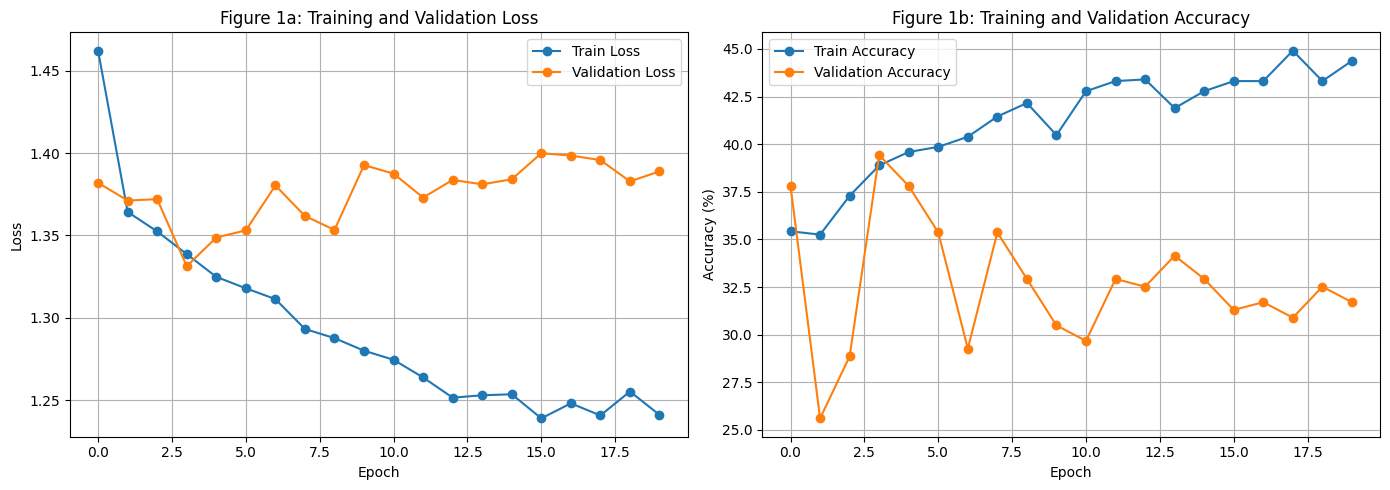

In [35]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Figure 1a: Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy', marker='o')
axes[1].plot(val_accs, label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Figure 1b: Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

##5c. Confusion Matrix

In [36]:
classes = val_loader8.dataset.classes

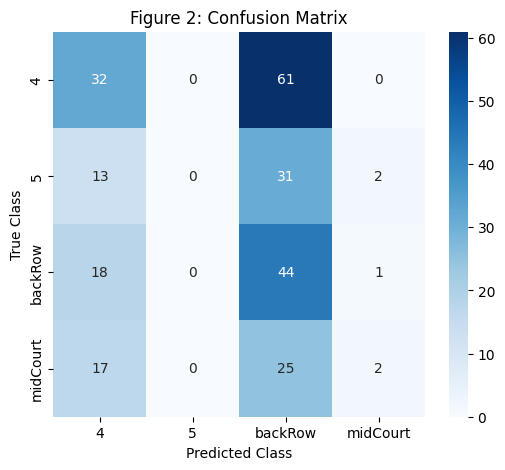

In [37]:
plt.figure(figsize=(6, 5))
cm = plot_confusion_matrix(simple_model, val_loader8, device, classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Figure 2: Confusion Matrix')
plt.show()

31.71% accuracy, but cannot predict 5 location.  Increase from original models in prediction variety, but observe vgg.

#6. Run VGG

Configuration

In [38]:
# Training configuration
NUM_EPOCHS = 20
LEARNING_RATE = 0.0001

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(vgg_model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_1059/3417175722.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


## 6a. Train

In [39]:
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("Starting training...")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(vgg_model, train_loader8, criterion, optimizer, device, scaler)

    # Evaluate
    val_loss, val_acc = evaluate(vgg_model, val_loader8, criterion, device)

    # Update scheduler
    scheduler.step(val_loss)

    # Save metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.2f} {val_loss:<12.4f} {val_acc:<12.2f}")

print("\nTraining complete!")

Starting training...
Epoch    Train Loss   Train Acc    Val Loss     Val Acc     
------------------------------------------------------------


/tmp/ipykernel_1059/3757051921.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


1        1.4668       34.28        1.3716       37.40       
2        1.3594       37.29        1.3678       39.43       
3        1.3469       38.00        1.3513       37.40       
4        1.3501       38.44        1.3418       36.59       
5        1.3401       37.47        1.3356       36.99       
6        1.3348       38.09        1.3561       36.18       
7        1.3395       38.18        1.3439       36.59       
8        1.3344       38.26        1.3485       38.21       
9        1.3226       38.80        1.3367       38.62       
10       1.3328       38.71        1.3383       38.21       
11       1.3234       39.68        1.3444       37.40       
12       1.3216       39.50        1.3333       38.21       
13       1.3181       40.21        1.3524       38.21       
14       1.3183       39.59        1.3430       38.62       
15       1.3155       40.57        1.3721       38.62       
16       1.3119       40.83        1.3746       38.21       
17       1.3138       39

##6b. Accuracy and Loss Plots

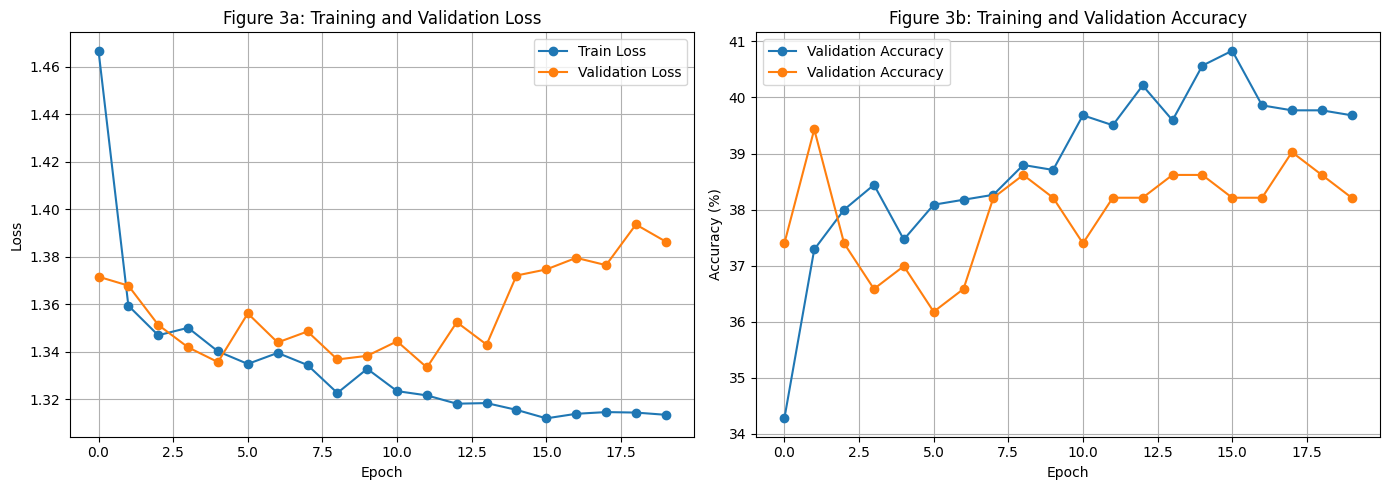

In [40]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Figure 3a: Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(train_accs, label='Validation Accuracy', marker='o')
axes[1].plot(val_accs, label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Figure 3b: Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6c. Confusion Matrix

In [41]:
classes = val_loader8.dataset.classes

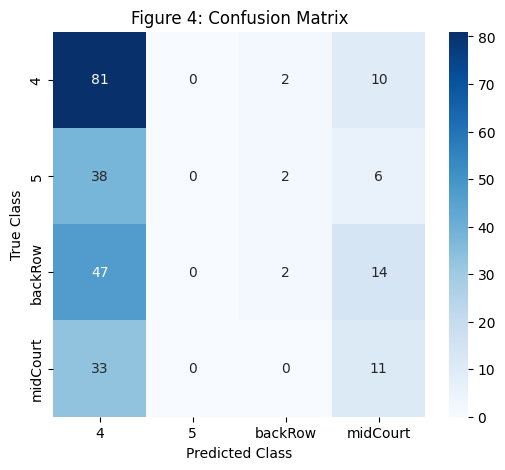

In [42]:
plt.figure(figsize=(6, 5))
cm = plot_confusion_matrix(vgg_model, val_loader8, device, classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Figure 4: Confusion Matrix')
plt.show()

Similar results, but slightly higher accuracy 38.21% and cannot predict 5 location.  However, both models heavily predict a 4 location compared to all others, but much higher prediction variation, so retain vgg grouped model.  Observe performance on test set.

# 7. Test set performance

In [ ]:
classes = test_loader8.dataset.classes
plt.figure(figsize=(6, 5))
cm = plot_confusion_matrix(vgg_model, test_loader8, device, classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Figure 4: Grouped VGG Confusion Matrix for Test Set')
plt.show()